In [1]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score ,recall_score ,precision_score
sys.path.append(str(Path("..")))
from src.dataset import train_data, train_loader,train_path,train_indices,val_indices, val_loader, ood_loader,ood_path
from torchvision import transforms,datasets
from torch.utils.data import Subset,DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

torch.Size([32, 3, 256, 256])
torch.Size([32])
tensor([3, 3, 1, 2, 5, 7, 3, 2, 5, 5])


In [2]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


# *StepLR*

In [3]:
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x
    
num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=30,
    gamma=0.1
)



num_epochs = 100

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_f1_scores = []
val_precision_scores = []
val_recall_scores = []

val_f1_scores_by_class = []
val_precision_scores_by_class = []
val_recall_scores_by_class = []

best_val_f1 = 0.0
best_epoch = 0

In [4]:
for epoch in range(num_epochs):

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = train_correct / train_total


    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            all_val_labels.extend(labels.cpu().numpy())
            all_val_predictions.extend(predicted.cpu().numpy())

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro"
    )

    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    val_f1_scores.append(val_f1)
    val_f1_scores_by_class.append(f1_score_by_class)


    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("F1_Score by each class")
    print(f1_score_by_class)

    print("=======================================================================================")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
    
        torch.save(
            model.state_dict(),
            "../models/StepLR.pth"
        )
    scheduler.step()

Epoch [1/100] | LR: 0.001000 | Train Loss: 1.5248 | Train Acc: 0.4849 | Val Loss: 0.9817 | Val Acc: 0.6575 | Val Macro F1: 0.6049
F1_Score by each class
[0.59591837 0.72268908 0.48888889 0.46153846 0.63783784 0.74796748
 0.89855072 0.28571429]
Epoch [2/100] | LR: 0.001000 | Train Loss: 0.6402 | Train Acc: 0.7781 | Val Loss: 0.5316 | Val Acc: 0.8068 | Val Macro F1: 0.7928
F1_Score by each class
[0.83529412 0.8358209  0.74226804 0.72146119 0.77714286 0.84070796
 0.92307692 0.66666667]
Epoch [3/100] | LR: 0.001000 | Train Loss: 0.3570 | Train Acc: 0.8795 | Val Loss: 0.5376 | Val Acc: 0.8055 | Val Macro F1: 0.7978
F1_Score by each class
[0.86666667 0.8220339  0.6626506  0.73359073 0.85227273 0.84444444
 0.89690722 0.7037037 ]
Epoch [4/100] | LR: 0.001000 | Train Loss: 0.1593 | Train Acc: 0.9452 | Val Loss: 0.6495 | Val Acc: 0.8151 | Val Macro F1: 0.8049
F1_Score by each class
[0.87179487 0.85585586 0.73584906 0.76363636 0.79245283 0.81222707
 0.93       0.67741935]
Epoch [5/100] | LR: 0.00

In [5]:

num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

model.load_state_dict(
    torch.load("../models/StepLR.pth")
)

model = model.to(device)

In [6]:
model.eval()

all_val_labels = []

all_val_predictions = []

all_probabilities = []

all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(outputs,dim=1)

        _, predicted = torch.max(outputs,1)
        
        val_total += labels.size(0)

        val_correct += (predicted == labels).sum().item()


        all_val_labels.extend(labels.cpu().numpy())

        all_val_predictions.extend(predicted.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

        all_logits.extend(outputs.cpu().numpy())


val_accuracy = val_correct / val_total


val_precision = precision_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_recall = recall_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_f1 = f1_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_precision_by_class = precision_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_recall_by_class = recall_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_f1_by_class = f1_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)
print(f"val Accuracy: {val_accuracy:.4f}")


print(
    f"val Macro Precision: "
    f"{val_precision:.4f}"
)

print(
    f"val Macro Recall: "
    f"{val_recall:.4f}"
)

print(
    f"val Macro F1: "
    f"{val_f1:.4f}"
)


print("val Precision by class:")
print(val_precision_by_class)

print("val Recall by class:")
print(val_recall_by_class)

print("val F1 by class:")
print(val_f1_by_class)

val Accuracy: 0.8521
val Macro Precision: 0.8613
val Macro Recall: 0.8492
val Macro F1: 0.8510
val Precision by class:
[0.94805195 0.91346154 0.61481481 0.75925926 0.90123457 0.98913043
 0.99019608 0.77419355]
val Recall by class:
[0.9125     0.91346154 0.86458333 0.74545455 0.79347826 0.81981982
 0.94392523 0.8       ]
val F1 by class:
[0.92993631 0.91346154 0.71861472 0.75229358 0.84393064 0.89655172
 0.96650718 0.78688525]


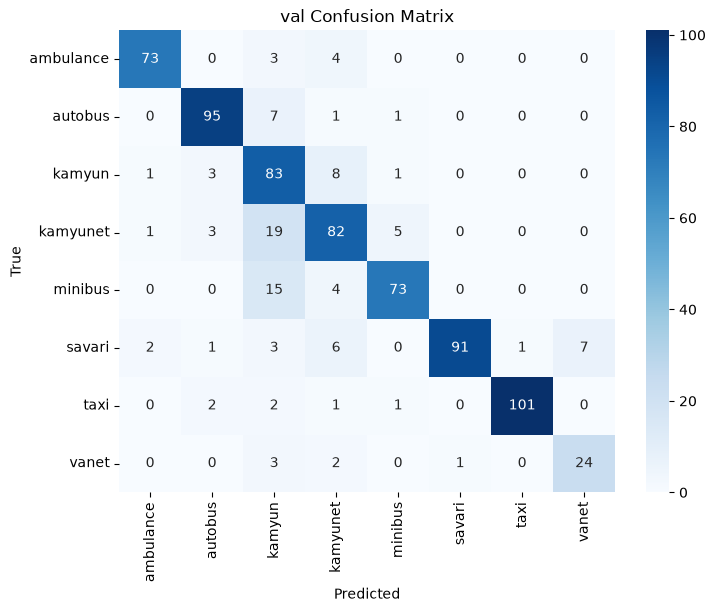

In [7]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

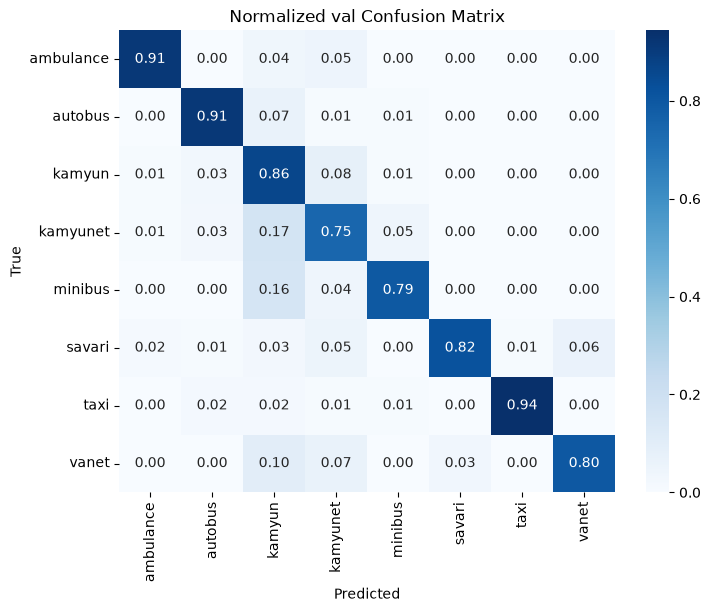

In [8]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()

# *ReduceLR*

In [9]:
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [10]:
num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=5
)

In [12]:
num_epochs = 100

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_f1_scores = []
val_f1_scores_by_class = []

best_val_f1 = 0.0
best_epoch = 0

In [13]:
for epoch in range(num_epochs):

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = train_correct / train_total


    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            all_val_labels.extend(labels.cpu().numpy())
            all_val_predictions.extend(predicted.cpu().numpy())

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro"
    )

    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    val_f1_scores.append(val_f1)
    val_f1_scores_by_class.append(f1_score_by_class)

    
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_loss)
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("F1_Score by each class")
    print(f1_score_by_class)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
    
        torch.save(
            model.state_dict(),
            "../models/ReduceLR.pth"
        )
    print("=======================================================================================")
    


Epoch [1/100] | LR: 0.001000 | Train Loss: 1.6001 | Train Acc: 0.4976 | Val Loss: 0.8512 | Val Acc: 0.6973 | Val Macro F1: 0.6644
F1_Score by each class
[0.70103093 0.79166667 0.54193548 0.57480315 0.6509434  0.77570093
 0.9009901  0.37837838]
Epoch [2/100] | LR: 0.001000 | Train Loss: 0.6854 | Train Acc: 0.7606 | Val Loss: 0.6175 | Val Acc: 0.7795 | Val Macro F1: 0.7393
F1_Score by each class
[0.86060606 0.80519481 0.66285714 0.68312757 0.77300613 0.82113821
 0.93       0.37837838]
Epoch [3/100] | LR: 0.001000 | Train Loss: 0.4066 | Train Acc: 0.8568 | Val Loss: 0.6157 | Val Acc: 0.7918 | Val Macro F1: 0.7834
F1_Score by each class
[0.83870968 0.90452261 0.70520231 0.71428571 0.79775281 0.79090909
 0.88659794 0.62921348]
Epoch [4/100] | LR: 0.001000 | Train Loss: 0.2768 | Train Acc: 0.9072 | Val Loss: 0.5313 | Val Acc: 0.8425 | Val Macro F1: 0.8295
F1_Score by each class
[0.86585366 0.87       0.72093023 0.77333333 0.82051282 0.88135593
 0.97652582 0.72727273]
Epoch [5/100] | LR: 0.00

In [14]:

num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

model.load_state_dict(
    torch.load("../models/ReduceLR.pth")
)

model = model.to(device)

In [15]:
model.eval()

all_val_labels = []

all_val_predictions = []

all_probabilities = []

all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(outputs,dim=1)

        _, predicted = torch.max(outputs,1)
        
        val_total += labels.size(0)

        val_correct += (predicted == labels).sum().item()


        all_val_labels.extend(labels.cpu().numpy())

        all_val_predictions.extend(predicted.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

        all_logits.extend(outputs.cpu().numpy())


val_accuracy = val_correct / val_total


val_precision = precision_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_recall = recall_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_f1 = f1_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_precision_by_class = precision_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_recall_by_class = recall_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_f1_by_class = f1_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)
print(f"val Accuracy: {val_accuracy:.4f}")


print(
    f"val Macro Precision: "
    f"{val_precision:.4f}"
)

print(
    f"val Macro Recall: "
    f"{val_recall:.4f}"
)

print(
    f"val Macro F1: "
    f"{val_f1:.4f}"
)


print("val Precision by class:")
print(val_precision_by_class)

print("val Recall by class:")
print(val_recall_by_class)

print("val F1 by class:")
print(val_f1_by_class)

val Accuracy: 0.8644
val Macro Precision: 0.8690
val Macro Recall: 0.8443
val Macro F1: 0.8525
val Precision by class:
[0.88095238 0.86363636 0.86746988 0.80188679 0.8        0.85245902
 0.98076923 0.9047619 ]
val Recall by class:
[0.925      0.91346154 0.75       0.77272727 0.86956522 0.93693694
 0.95327103 0.63333333]
val F1 by class:
[0.90243902 0.88785047 0.80446927 0.78703704 0.83333333 0.89270386
 0.96682464 0.74509804]


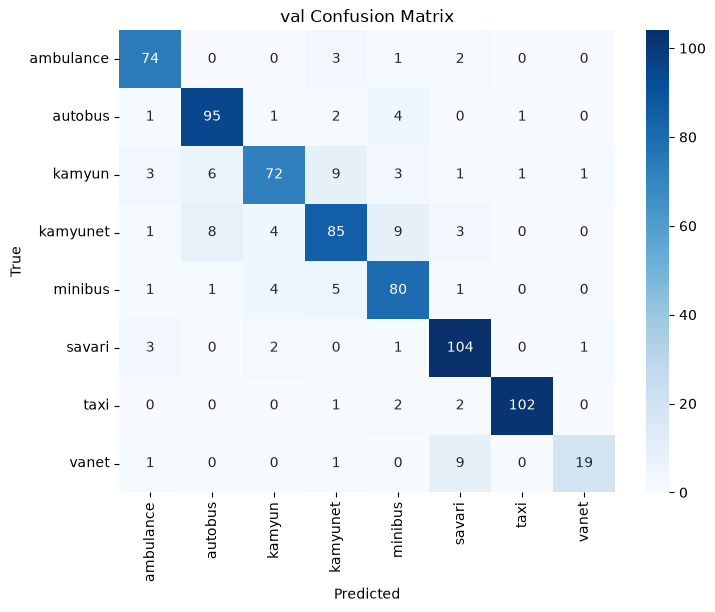

In [16]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

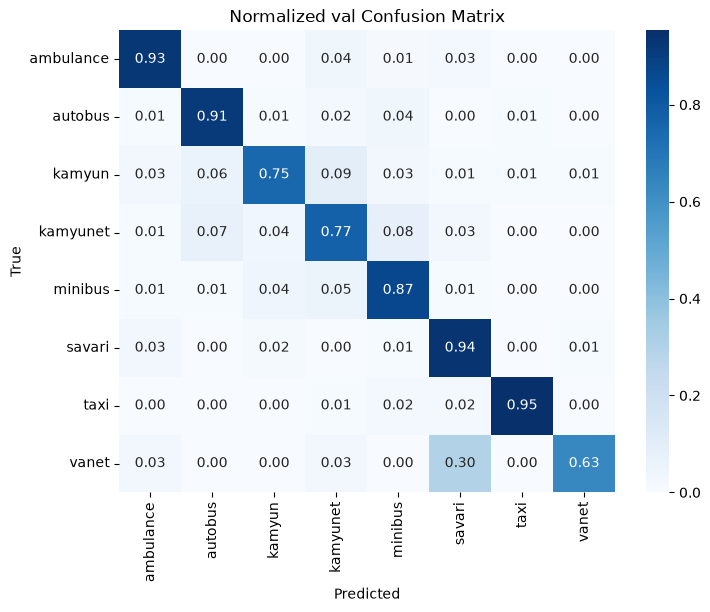

In [17]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()